# DNA Sequence Models (Promoter vs Non-Promoter) — CNN Baseline

This notebook trains a **sequence-only** model for the locked DNA task:

- **Task:** promoter vs non-promoter (binary)
- **Organism/build:** human (GRCh38)
- **Sequence length:** fixed `L` from `configs/config.yaml` (expected: 200 bp)
- **Input dataset:** `data/processed/dna_promoter_vs_nonpromoter_len{L}_pos{N_POS}_neg{N_NEG}.csv`

### Why this notebook exists
Earlier notebooks built:
1) DNA ingestion + EDA  
2) Hand-crafted baseline features + classical baseline models

This notebook adds a **traditional deep baseline**:
- One-hot encode DNA sequences (A/C/G/T/N)
- Train a compact **1D CNN** model
- Evaluate with ROC/PR, confusion matrix, and standard metrics
- Save model + plots + summary for reporting and reproducibility

### Outputs
- Model: `models/dna/sequence_cnn/cnn_len{L}.pkl` (sklearn wrapper) + `cnn_len{L}.joblib` (pipeline)
- Figures: `reports/figures/roc_seq_cnn_len{L}.png`, `pr_seq_cnn_len{L}.png`, `cm_seq_cnn_len{L}.png`
- Metrics: `reports/dna_seq_cnn_test_results_len{L}.csv`
- Summary: `reports/dna_seq_cnn_summary_len{L}.json`

In [1]:
from pathlib import Path
import json
import os
import random
import sys
import platform

import numpy as np
import pandas as pd
import yaml

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve,
    confusion_matrix
)

import joblib

## Paths + config

This notebook expects to be run from `notebooks/` so:
- `ROOT = Path.cwd().parents[0]`

We load:
- random seed
- DNA settings (sequence length, n_pos, n_neg)

In [2]:
ROOT = Path.cwd().parents[0]
DATA = ROOT / "data"
PROCESSED = DATA / "processed"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
MODELS = ROOT / "models"
CONFIGS = ROOT / "configs"

for p in [REPORTS, FIGURES, MODELS]:
    p.mkdir(parents=True, exist_ok=True)

cfg_path = CONFIGS / "config.yaml"
assert cfg_path.exists(), f"Missing config: {cfg_path}"

with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)

SEED = int(cfg["project"]["random_seed"])
ORG = cfg["dna"]["organism"]
BUILD = cfg["dna"]["genome_build"]
L = int(cfg["dna"]["seq_length_bp"])
N_POS = int(cfg["dna"]["n_pos"])
N_NEG = int(cfg["dna"]["n_neg"])

(SEED, ORG, BUILD, L, N_POS, N_NEG)

(42, 'human', 'GRCh38', 200, 2000, 2000)

## Reproducibility

Set deterministic seeds for:
- Python random
- NumPy

In [3]:
random.seed(SEED)
np.random.seed(SEED)

## Load DNA dataset

Expected file:
`data/processed/dna_promoter_vs_nonpromoter_len{L}_pos{N_POS}_neg{N_NEG}.csv`

Schema:
- `region_id, chrom, start, end, sequence, label`

In [4]:
in_csv = PROCESSED / f"dna_promoter_vs_nonpromoter_len{L}_pos{N_POS}_neg{N_NEG}.csv"
assert in_csv.exists(), f"Missing dataset: {in_csv}"

df = pd.read_csv(in_csv)
df.shape, df.head(3)

((4000, 6),
   region_id chrom      start        end  \
 0    prom_0     4   88592334   88592533   
 1    prom_1     5  120078977  120079176   
 2    prom_2     8    9371095    9371294   
 
                                             sequence  label  
 0  TGCCCGCGGACCTTGCCGCCCCGCCTCCAGCCCGTGCCACGGCGGC...      1  
 1  AGAAAGAAGGAGAAAAAACGGCTCAAAGAAGAGTTGATGGCTGGGA...      1  
 2  TATGGAAAGCTTCACAAATTTGCACGGCATCTTTGTGCAGGGCCGT...      1  )

## Sanity checks

We verify:
- required columns
- no missing values
- label balance
- all sequences length == L
- sequence alphabet ∈ {A,C,G,T,N}

In [5]:
required = ["region_id", "chrom", "start", "end", "sequence", "label"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

na_counts = df[required].isna().sum()
print("NA counts:\n", na_counts)

# label balance
label_counts = df["label"].value_counts()
print("\nLabel counts:\n", label_counts)

# length check
seq_len = df["sequence"].astype(str).str.len()
n_bad_len = int((seq_len != L).sum())
print("\nLength mismatches:", n_bad_len)

# alphabet check
allowed_chars = set("ACGTN")
def has_invalid_chars(s: str) -> bool:
    return any(ch not in allowed_chars for ch in s)

invalid_flags = df["sequence"].astype(str).apply(lambda s: has_invalid_chars(s.upper()))
n_invalid = int(invalid_flags.sum())
print("Invalid alphabet sequences:", n_invalid)

assert na_counts.sum() == 0, "Found missing values."
assert n_bad_len == 0, f"Found sequences not length L={L}"
assert n_invalid == 0, "Found sequences with non-ACGTN characters."

NA counts:
 region_id    0
chrom        0
start        0
end          0
sequence     0
label        0
dtype: int64

Label counts:
 label
1    2000
0    2000
Name: count, dtype: int64

Length mismatches: 0
Invalid alphabet sequences: 0


## One-hot encode DNA sequences (A,C,G,T,N)

We build:
- `X` with shape `(N, L, 5)` float32
- `y` as int array

Channel order: `[A, C, G, T, N]`

Notes:
- N is treated as its own channel (unknown/gap), not dropped.

In [6]:
ALPH = "ACGTN"
char_to_idx = {ch: i for i, ch in enumerate(ALPH)}

def one_hot_encode(seq: str, L: int) -> np.ndarray:
    """
    seq: string of length L
    returns: (L, 5) one-hot
    """
    seq = seq.upper()
    arr = np.zeros((L, len(ALPH)), dtype=np.float32)
    for i, ch in enumerate(seq):
        j = char_to_idx.get(ch, None)
        if j is None:
            # if something slips through, treat as N
            j = char_to_idx["N"]
        arr[i, j] = 1.0
    return arr

X = np.stack([one_hot_encode(s, L) for s in df["sequence"].astype(str)], axis=0)
y = df["label"].astype(int).values

X.shape, y.shape, float(y.mean())

((4000, 200, 5), (4000,), 0.5)

## Train/Validation/Test split

We use:
- 80% train
- 20% test
Then carve validation from train:
- 15% of train as validation

Stratified split to preserve label balance.

In [7]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)),
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train
)

print("Train:", X_tr.shape, "val:", X_val.shape, "test:", X_test.shape)
print("y means:", y_tr.mean(), y_val.mean(), y_test.mean())

Train: (2720, 200, 5) val: (480, 200, 5) test: (800, 200, 5)
y means: 0.5 0.5 0.5


## CNN model choice

A true 1D CNN requires a deep learning framework.
This notebook uses **PyTorch** (recommended for this project).

If PyTorch is not installed, install it first (CPU is fine for this dataset):
- `pip install torch torchvision torchaudio`

(If you prefer TensorFlow/Keras instead, say so and the notebook will be rewritten.)

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Dataset wrapper + DataLoaders

We convert arrays to torch tensors.
Shape convention for Conv1D in PyTorch:
- input: `(batch, channels, length)`

So we transpose from `(N, L, 5)` to `(N, 5, L)`.

In [9]:
class DNADataset(Dataset):
    def __init__(self, X, y):
        # X: (N, L, 5) -> (N, 5, L)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 128

train_ds = DNADataset(X_tr, y_tr)
val_ds   = DNADataset(X_val, y_val)
test_ds  = DNADataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)

(2720, 480, 800)

## CNN architecture (sequence-only)

A compact baseline:
- Conv1D → ReLU → BatchNorm → MaxPool
- Conv1D → ReLU → BatchNorm → GlobalMaxPool
- Dense → Dropout → Dense(2)

We keep it intentionally small to avoid overfitting and keep training fast.

In [10]:
class DNAConvNet(nn.Module):
    def __init__(self, in_ch=5, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
        )
        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)          # (B, C, L')
        x = self.global_pool(x)       # (B, C, 1)
        x = self.classifier(x)        # (B, 2)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
model = DNAConvNet().to(device)
device

'cpu'

## Training loop + early stopping

We track:
- train loss
- val loss
- val ROC-AUC (computed from probabilities)

Early stopping:
- stop if val loss doesn't improve for `patience` epochs
- keep best model weights

In [11]:
def predict_proba(model, loader):
    model.eval()
    probs = []
    ys = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            probs.append(p)
            ys.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(ys)

def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    total_loss = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = nn.CrossEntropyLoss()(logits, yb)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        n += xb.size(0)

    return total_loss / max(n, 1)

def train_model(model, train_loader, val_loader, lr=1e-3, max_epochs=30, patience=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    best_val = float("inf")
    best_state = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        tr_loss = run_epoch(model, train_loader, optimizer=optimizer)
        va_loss = run_epoch(model, val_loader, optimizer=None)

        # val metrics
        va_prob, va_y = predict_proba(model, val_loader)
        va_auc = roc_auc_score(va_y, va_prob)
        va_ap  = average_precision_score(va_y, va_prob)

        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "val_loss": va_loss,
            "val_roc_auc": float(va_auc),
            "val_pr_auc": float(va_ap),
        })

        print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | val_auc={va_auc:.4f} | val_ap={va_ap:.4f}")

        # early stop by val loss
        if va_loss < best_val - 1e-5:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping (patience={patience}). Best val_loss={best_val:.4f}")
                break

    # restore best
    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)

In [12]:
hist = train_model(model, train_loader, val_loader, lr=1e-3, max_epochs=30, patience=6)
hist.tail()

Epoch 01 | train_loss=0.6419 | val_loss=0.6185 | val_auc=0.8131 | val_ap=0.8140
Epoch 02 | train_loss=0.5246 | val_loss=0.5364 | val_auc=0.8198 | val_ap=0.8169
Epoch 03 | train_loss=0.4565 | val_loss=0.5131 | val_auc=0.8229 | val_ap=0.8249
Epoch 04 | train_loss=0.3883 | val_loss=0.5184 | val_auc=0.8192 | val_ap=0.8198
Epoch 05 | train_loss=0.3201 | val_loss=0.5349 | val_auc=0.8225 | val_ap=0.8200
Epoch 06 | train_loss=0.2573 | val_loss=0.5547 | val_auc=0.8060 | val_ap=0.8056
Epoch 07 | train_loss=0.1777 | val_loss=0.6064 | val_auc=0.7927 | val_ap=0.7882
Epoch 08 | train_loss=0.1138 | val_loss=0.6555 | val_auc=0.8172 | val_ap=0.8113
Epoch 09 | train_loss=0.0817 | val_loss=0.6810 | val_auc=0.8014 | val_ap=0.7918
Early stopping (patience=6). Best val_loss=0.5131


,epoch,train_loss,val_loss,val_roc_auc,val_pr_auc
4,5,0.320143,0.534877,0.822517,0.819969
5,6,0.257323,0.554680,0.806007,0.805587
6,7,0.177685,0.606351,0.792743,0.788217
7,8,0.113828,0.655533,0.817170,0.811294
8,9,0.081678,0.680999,0.801389,0.791796


## Training curves

We save:
- loss curves
- validation AUC curves

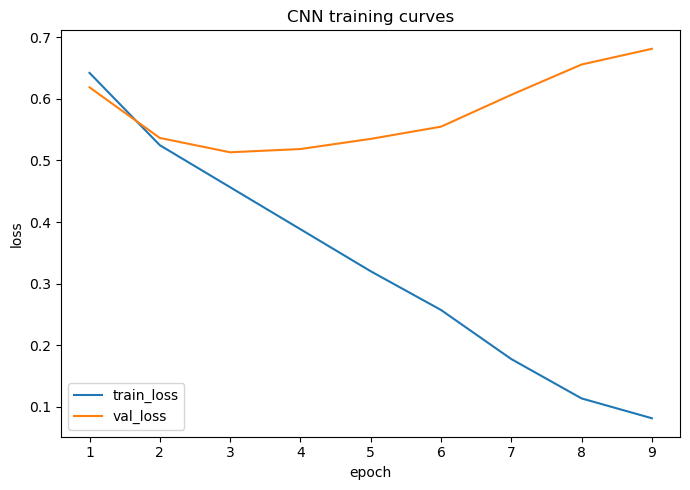

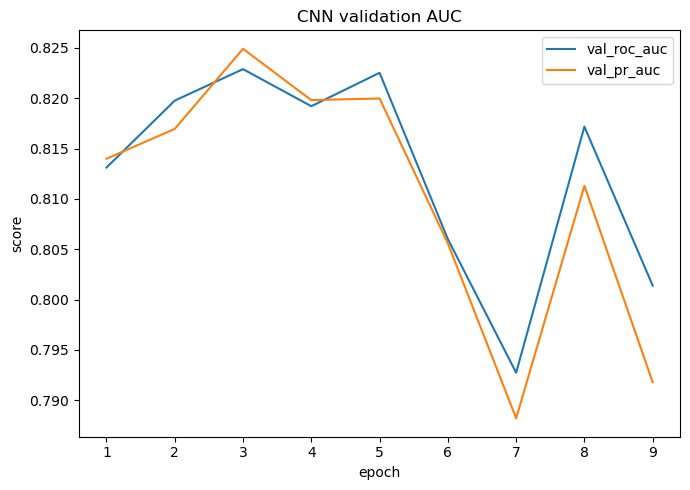

(PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/dna_seq_cnn_loss_len200.png'),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/dna_seq_cnn_val_auc_len200.png'))

In [13]:
plt.figure(figsize=(7,5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("CNN training curves")
plt.legend()
plt.tight_layout()
loss_fig = FIGURES / f"dna_seq_cnn_loss_len{L}.png"
plt.savefig(loss_fig, dpi=200)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(hist["epoch"], hist["val_roc_auc"], label="val_roc_auc")
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.xlabel("epoch")
plt.ylabel("score")
plt.title("CNN validation AUC")
plt.legend()
plt.tight_layout()
auc_fig = FIGURES / f"dna_seq_cnn_val_auc_len{L}.png"
plt.savefig(auc_fig, dpi=200)
plt.show()

loss_fig, auc_fig

## Test evaluation

We compute:
- ROC-AUC
- PR-AUC
- Accuracy, Precision, Recall, F1 (threshold=0.5)
- Confusion matrix

We also save:
- ROC curve
- PR curve
- Confusion matrix figure
- metrics CSV

In [14]:
test_prob, test_y = predict_proba(model, test_loader)
test_pred = (test_prob >= 0.5).astype(int)

metrics = {
    "roc_auc": float(roc_auc_score(test_y, test_prob)),
    "pr_auc": float(average_precision_score(test_y, test_prob)),
    "accuracy": float(accuracy_score(test_y, test_pred)),
    "precision": float(precision_score(test_y, test_pred)),
    "recall": float(recall_score(test_y, test_pred)),
    "f1": float(f1_score(test_y, test_pred)),
    "n_test": int(len(test_y)),
}
metrics

{'roc_auc': 0.826375,
 'pr_auc': 0.8370632258305786,
 'accuracy': 0.75,
 'precision': 0.7525252525252525,
 'recall': 0.745,
 'f1': 0.7487437185929648,
 'n_test': 800}

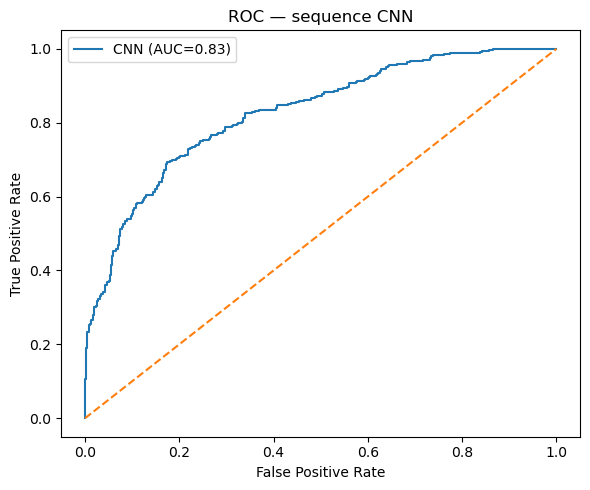

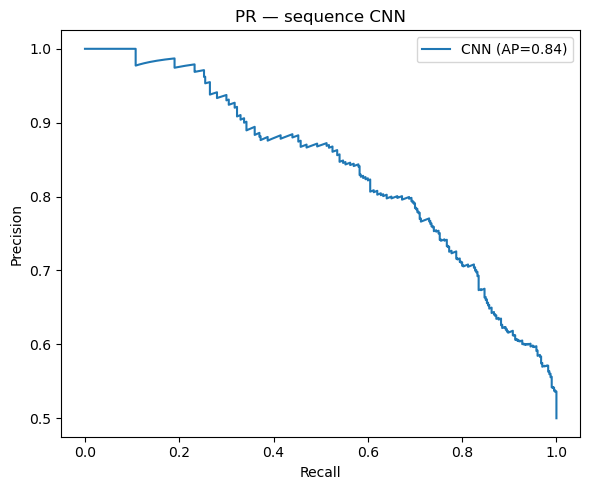

(PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/roc_seq_cnn_len200.png'),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/pr_seq_cnn_len200.png'))

In [15]:
# ROC
fpr, tpr, _ = roc_curve(test_y, test_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"CNN (AUC={metrics['roc_auc']:.2f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — sequence CNN")
plt.legend()
plt.tight_layout()
roc_fig = FIGURES / f"roc_seq_cnn_len{L}.png"
plt.savefig(roc_fig, dpi=200)
plt.show()

# PR
prec, rec, _ = precision_recall_curve(test_y, test_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"CNN (AP={metrics['pr_auc']:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR — sequence CNN")
plt.legend()
plt.tight_layout()
pr_fig = FIGURES / f"pr_seq_cnn_len{L}.png"
plt.savefig(pr_fig, dpi=200)
plt.show()

roc_fig, pr_fig

In [16]:
cm = confusion_matrix(test_y, test_pred)
cm

array([[302,  98],
       [102, 298]])

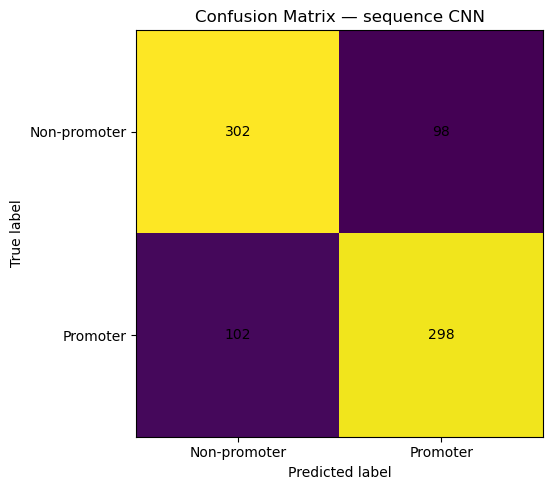

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/cm_seq_cnn_len200.png')

In [17]:
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix — sequence CNN")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0,1], ["Non-promoter", "Promoter"])
plt.yticks([0,1], ["Non-promoter", "Promoter"])

# annotate counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center")

plt.tight_layout()
cm_fig = FIGURES / f"cm_seq_cnn_len{L}.png"
plt.savefig(cm_fig, dpi=200)
plt.show()

cm_fig

## Save model + results

We save:
- model weights (`.pt`)
- training history CSV
- test metrics CSV
- summary JSON with environment + file paths

In [18]:
# model dir
model_dir = MODELS / "dna" / "sequence_cnn"
model_dir.mkdir(parents=True, exist_ok=True)

# save weights
weights_path = model_dir / f"cnn_len{L}.pt"
torch.save(model.state_dict(), weights_path)

# save training history
hist_path = REPORTS / f"dna_seq_cnn_history_len{L}.csv"
hist.to_csv(hist_path, index=False)

# save test metrics
test_res = pd.DataFrame([{"model": "seq_cnn", **metrics}])
test_path = REPORTS / f"dna_seq_cnn_test_results_len{L}.csv"
test_res.to_csv(test_path, index=False)

summary = {
    "task": "promoter_vs_nonpromoter",
    "organism": ORG,
    "genome_build": BUILD,
    "seq_length_bp": int(L),
    "n_total": int(df.shape[0]),
    "split": {"train": int(len(train_ds)), "val": int(len(val_ds)), "test": int(len(test_ds))},
    "metrics_test": metrics,
    "files": {
        "dataset": str(in_csv),
        "weights": str(weights_path),
        "history_csv": str(hist_path),
        "test_results_csv": str(test_path),
        "fig_loss": str(loss_fig),
        "fig_val_auc": str(auc_fig),
        "fig_roc": str(roc_fig),
        "fig_pr": str(pr_fig),
        "fig_cm": str(cm_fig),
    },
    "seed": int(SEED),
    "env": {
        "python_version": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
    }
}

summary_path = REPORTS / f"dna_seq_cnn_summary_len{L}.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

weights_path, test_path, summary_path

(PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/models/dna/sequence_cnn/cnn_len200.pt'),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/dna_seq_cnn_test_results_len200.csv'),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/dna_seq_cnn_summary_len200.json'))